# Multi-Head Attention from Scratch

A walk-through of the math inside a transformer's attention block, written for someone who has seen the equations but wants to *see* the matrices change shape.

We build it up in three pieces:

1. Project the input into three matrices: Q (queries), K (keys), V (values).
2. Compute scaled dot-product attention: how much each token should look at every other token.
3. Wrap the same thing into multiple parallel "heads" so the model can pay attention to several patterns at once.

Every step has a heatmap so you can watch the matrices light up.

In [1]:
# Everything we need: torch for the math, matplotlib for the pictures.
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Fix the seed so the matrices look the same every time you re-run the notebook.
torch.manual_seed(0)

# Tiny helper so we don't repeat ourselves when drawing heatmaps.
def heatmap(ax, matrix, title, xticklabels=None, yticklabels=None, annotate=False, cmap='RdBu_r'):
    """Draw a 2-D tensor as a colored grid on the given axis."""
    data = matrix.detach().numpy() if torch.is_tensor(matrix) else matrix
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_title(title)
    if xticklabels is not None:
        ax.set_xticks(range(len(xticklabels)))
        ax.set_xticklabels(xticklabels, rotation=45, ha='right')
    if yticklabels is not None:
        ax.set_yticks(range(len(yticklabels)))
        ax.set_yticklabels(yticklabels)
    if annotate:
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center',
                        color='white' if abs(data[i, j]) > (abs(data).max() / 2) else 'black',
                        fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im

## A toy input

Real transformers tokenize text and then look up an embedding vector for each token. We'll skip the lookup and just hand-roll five random embedding vectors so the matrix shapes are small enough to actually look at.

- **seq_len = 5** tokens.
- **d_model = 8** numbers per token (the "embedding dimension").

So our input is a `(5, 8)` matrix: one row per token.

input shape: (5, 8)


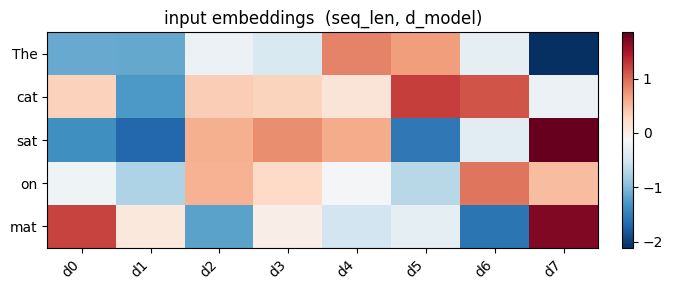

In [2]:
# Five tokens. The actual strings don't matter for the math, they're just labels for the plots.
tokens = ["The", "cat", "sat", "on", "mat"]
seq_len = len(tokens)

# Each token becomes an 8-dimensional vector. 8 is small enough to read, big enough
# to split into a few attention heads later.
d_model = 8

# Random vectors stand in for real word embeddings.
x = torch.randn(seq_len, d_model)
print("input shape:", tuple(x.shape))  # (5, 8)

# Show what the embeddings look like.
fig, ax = plt.subplots(figsize=(7, 3))
heatmap(ax, x, "input embeddings  (seq_len, d_model)",
        xticklabels=[f'd{i}' for i in range(d_model)],
        yticklabels=tokens)
plt.tight_layout()
plt.show()

## Step 1 — project into queries, keys, and values

Attention asks each token *"who in the sentence should I listen to?"* To do that we need three different views of the same token:

- **Q (query)** — what *I'm* looking for.
- **K (key)** — what *I* advertise about myself, used by others to decide if they care about me.
- **V (value)** — the actual content I'll hand over if someone attends to me.

Each view is just the input multiplied by its own learned weight matrix. In a real model these weights get trained; here we randomly initialize them so we can see the shapes.

Q: (5, 8)  K: (5, 8)  V: (5, 8)


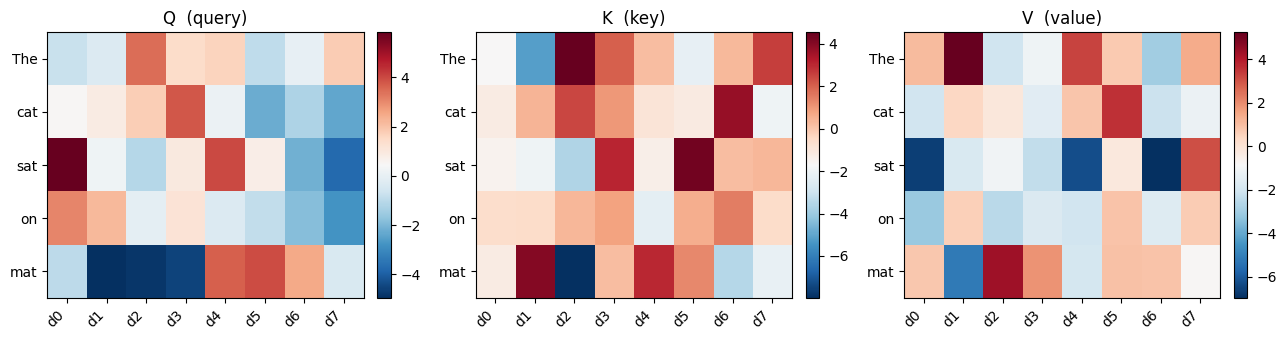

In [3]:
# Three separate weight matrices, each (d_model, d_model). In a real model these are nn.Linear layers
# whose weights are learned during training.
W_q = torch.randn(d_model, d_model)
W_k = torch.randn(d_model, d_model)
W_v = torch.randn(d_model, d_model)

# Project the input three different ways. Same input, three different lenses.
Q = x @ W_q   # (seq_len, d_model)
K = x @ W_k   # (seq_len, d_model)
V = x @ W_v   # (seq_len, d_model)

print("Q:", tuple(Q.shape), " K:", tuple(K.shape), " V:", tuple(V.shape))

# Three heatmaps side-by-side so you can see they are different views of the same five tokens.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, mat, name in zip(axes, [Q, K, V], ['Q  (query)', 'K  (key)', 'V  (value)']):
    heatmap(ax, mat, name,
            xticklabels=[f'd{i}' for i in range(d_model)],
            yticklabels=tokens)
plt.tight_layout()
plt.show()

## Step 2 — scaled dot-product attention

Now the heart of attention. For every pair of tokens (i, j) we ask: *"how compatible is i's query with j's key?"* That's a dot product.

Doing this for all pairs at once is just one matrix multiply: `Q @ K.T`. The result is a `(seq_len, seq_len)` square — row `i`, column `j` = how much token `i` cares about token `j`.

Two extra steps:

1. **Scale by `sqrt(d_k)`** so dot products of high-dimensional vectors don't blow up into the saturated region of softmax. `d_k` is the per-head key dimension (here it equals `d_model` because we only have one head so far).
2. **Softmax over each row** so every row sums to 1 — those are the attention *weights*, basically a probability distribution over "which token to listen to".

row sums of attention weights: [1.0, 1.0000001192092896, 0.9999999403953552, 0.9999999403953552, 1.0]


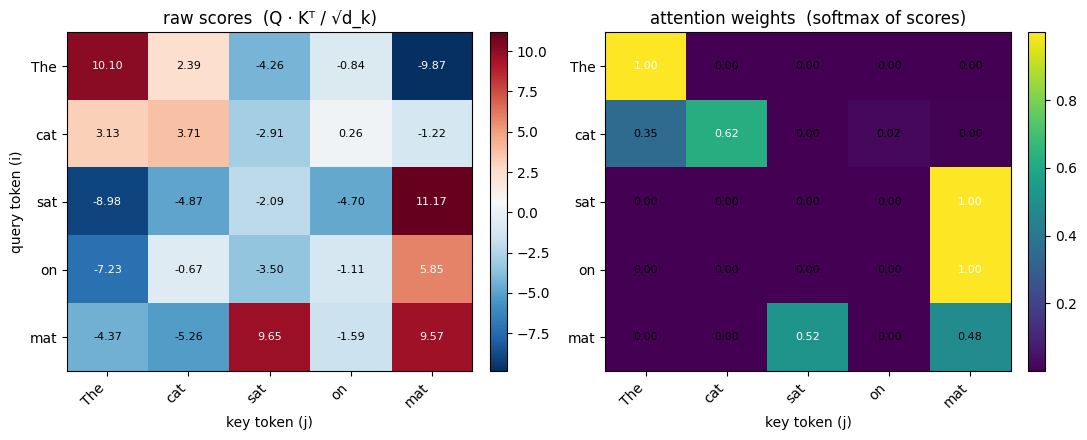

In [4]:
# Dimension we scale by. For single-head attention this is just d_model.
d_k = Q.shape[-1]

# 1. Raw compatibility scores: a (seq_len, seq_len) matrix of dot products.
#    K.T transposes K so the shapes line up: (seq_len, d_k) @ (d_k, seq_len) -> (seq_len, seq_len).
scores = Q @ K.T / np.sqrt(d_k)

# 2. Softmax over the LAST axis (each row) -> each row sums to 1.
attn = F.softmax(scores, dim=-1)

# Sanity check: each row of the attention matrix should sum to 1.
print("row sums of attention weights:", attn.sum(dim=-1).tolist())

# Two heatmaps: the raw scores (could be any real number) and the softmaxed weights (in [0, 1]).
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
heatmap(axes[0], scores, 'raw scores  (Q · Kᵀ / √d_k)',
        xticklabels=tokens, yticklabels=tokens, annotate=True, cmap='RdBu_r')
heatmap(axes[1], attn, 'attention weights  (softmax of scores)',
        xticklabels=tokens, yticklabels=tokens, annotate=True, cmap='viridis')
axes[0].set_ylabel('query token (i)')
axes[0].set_xlabel('key token (j)')
axes[1].set_xlabel('key token (j)')
plt.tight_layout()
plt.show()

Read the right-hand heatmap row-by-row. Row `i` is *"when I am token i, here is the probability distribution I use to mix the other tokens' values"*. Brighter cells = more attention.

## Step 3 — mix the values

Multiply the attention weights by V. Row `i` of the output is the weighted average of all value vectors, weighted by how much token `i` attended to each one.

output shape: (5, 8)


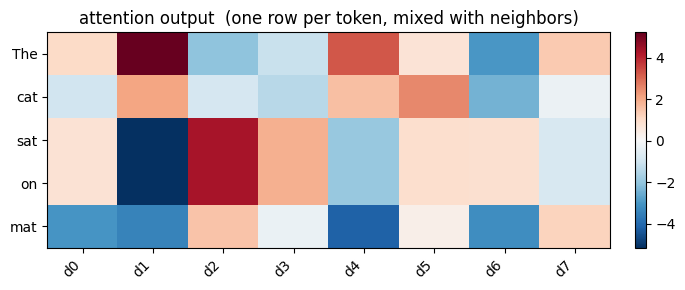

In [5]:
# Weighted sum of value vectors. Shape: (seq_len, seq_len) @ (seq_len, d_model) -> (seq_len, d_model).
output = attn @ V
print("output shape:", tuple(output.shape))

fig, ax = plt.subplots(figsize=(7, 3))
heatmap(ax, output, 'attention output  (one row per token, mixed with neighbors)',
        xticklabels=[f'd{i}' for i in range(d_model)],
        yticklabels=tokens)
plt.tight_layout()
plt.show()

Same shape as the input. The transformer can now stack another attention layer on top, or send this through a feed-forward block.

## Multi-head attention

One attention pattern is limiting — the model might want to track *several* different relationships at once (syntactic dependencies, coreference, position, ...). Solution: do the whole thing in parallel `H` times with different weight matrices, then concatenate.

The trick: instead of `H` separate `(d_model, d_model)` projections, we use one big `(d_model, d_model)` projection and *reshape* the result into `H` heads of size `d_model / H` each. Cheaper, same idea.

With `d_model = 8` and `n_heads = 4`, each head sees `d_k = 2` features. Tiny on purpose so the visualizations stay legible.

In [6]:
class MultiHeadAttention(nn.Module):
    """Vanilla multi-head self-attention, written for clarity over speed."""

    def __init__(self, d_model, n_heads):
        super().__init__()
        # d_model must split evenly across heads.
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # size of each head

        # Four linear layers, each (d_model -> d_model). The first three produce
        # Q/K/V; the last one mixes the concatenated heads back together at the end.
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        # x has shape (batch, seq_len, d_model). We'll keep the batch dim throughout.
        B, T, _ = x.shape

        # 1. Project into Q, K, V. Still shape (B, T, d_model).
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # 2. Split the last dimension into (n_heads, d_k) and move heads to the front
        #    so each head can be processed as its own (T, d_k) matrix.
        #    Resulting shape: (B, n_heads, T, d_k).
        def split_heads(t):
            return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        Q, K, V = split_heads(Q), split_heads(K), split_heads(V)

        # 3. Scaled dot-product attention, done in parallel across heads.
        #    Q @ K.transpose(-2, -1) -> (B, n_heads, T, T)
        scores = Q @ K.transpose(-2, -1) / np.sqrt(self.d_k)
        attn = F.softmax(scores, dim=-1)

        # 4. Weighted values. Shape: (B, n_heads, T, d_k).
        head_out = attn @ V

        # 5. Re-merge the heads back into a single (B, T, d_model) tensor.
        #    First put heads behind the time axis, then collapse them.
        head_out = head_out.transpose(1, 2).contiguous().view(B, T, self.d_model)

        # 6. One last linear projection to mix information across heads.
        out = self.W_o(head_out)

        # We also return attn so we can visualize what each head is looking at.
        return out, attn

In [7]:
# Build the module and run it on our toy sentence. The unsqueeze(0) adds a batch
# dimension of size 1 — the module expects (batch, seq_len, d_model).
mha = MultiHeadAttention(d_model=8, n_heads=4)
out, attn = mha(x.unsqueeze(0))

print("output shape:           ", tuple(out.shape))      # (1, 5, 8)
print("attention weights shape:", tuple(attn.shape))     # (1, 4, 5, 5)  -> one (5,5) matrix per head

output shape:            (1, 5, 8)
attention weights shape: (1, 4, 5, 5)


### What each head is paying attention to

Below is one heatmap per head. Each row is still *"when I am this token, who am I looking at?"* but now we have four different views. With trained weights you'd often see one head latching onto position, another onto syntax, etc. With random weights you mostly see arbitrary patterns — but the point is the model *can* learn four different patterns in parallel.

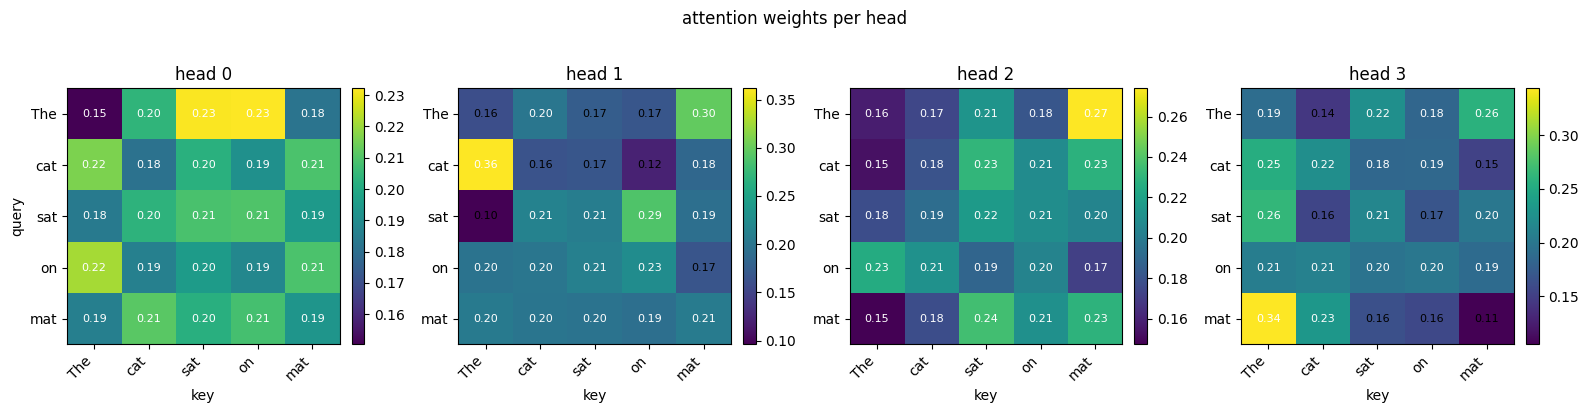

In [8]:
# Drop the batch dimension for plotting -> (n_heads, T, T).
attn_heads = attn[0]
n_heads = attn_heads.shape[0]

fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 4))
for h, ax in enumerate(axes):
    heatmap(ax, attn_heads[h], f'head {h}',
            xticklabels=tokens, yticklabels=tokens,
            annotate=True, cmap='viridis')
    ax.set_xlabel('key')
    if h == 0:
        ax.set_ylabel('query')
plt.suptitle('attention weights per head', y=1.02)
plt.tight_layout()
plt.show()

## Quick sanity check against PyTorch's built-in

PyTorch ships `nn.MultiheadAttention`. Worth confirming our hand-rolled version produces the same *shapes* (the numbers will differ because the weight inits are independent).

In [9]:
# PyTorch's built-in expects (seq_len, batch, d_model) by default — we'll just match shapes here.
ref = nn.MultiheadAttention(embed_dim=8, num_heads=4, batch_first=True)
ref_out, ref_attn = ref(x.unsqueeze(0), x.unsqueeze(0), x.unsqueeze(0))

print("ours :", tuple(out.shape), tuple(attn.shape))
print("torch:", tuple(ref_out.shape), tuple(ref_attn.shape))
print("(torch averages attention across heads by default, hence the missing head dim.)")

ours : (1, 5, 8) (1, 4, 5, 5)
torch: (1, 5, 8) (1, 5, 5)
(torch averages attention across heads by default, hence the missing head dim.)


## What to take away

- Attention is three matrix multiplies and a softmax. The Q/K/V naming is just dressing.
- The (seq_len × seq_len) attention matrix is the interesting one — it's what people mean when they say *"transformers attend to other tokens"*.
- Multi-head is the same operation in parallel with smaller per-head dimensions, then concatenated. It lets the model learn several different attention patterns at once for the same cost as one big one.
- Masking (for causal / autoregressive models) is one extra step you slot in right before the softmax — add `-inf` to positions you don't want a token to see, and softmax pushes them to zero.